In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
import pandas as pd
import numpy as np

# 1. Configuración de Reproducibilidad y Tamaño
n_rows = 1_000_000
np.random.seed(42)

print("Generando data_sp8_s1.csv (1M registros)...")

# --- 2. Definición de Categorías con Pesos ---
states = ['CDMX', 'Jalisco', 'Nuevo León', 'Veracruz', 'Puebla', 'Yucatán', 'Sonora', 'Oaxaca']
soda_levels = ['Daily', 'Weekly', 'Occasional', 'Never']
insurance = ['Public', 'Private', 'Premium']

# Generación de vectores categóricos base
soda_col = np.random.choice(soda_levels, n_rows, p=[0.2, 0.3, 0.3, 0.2])
state_col = np.random.choice(states, n_rows)
insur_col = np.random.choice(insurance, n_rows, p=[0.6, 0.3, 0.1])
gender_col = np.random.choice(['F', 'M', 'NB'], n_rows)

# --- 3. Generación Numérica con "Grupos Forzados" ---
# Inicializamos para llenar por grupos
age = np.random.randint(18, 85, n_rows)
bmi = np.zeros(n_rows)
bp_sys = np.zeros(n_rows)
glucose = np.zeros(n_rows)

# Aplicamos parámetros diferenciados por grupo de 'soda' para romper la homogeneidad
# Esto garantiza que al usar hue='soda' se vean clusters separados
params = {
    'Daily':      {'bmi_mu': 34.0, 'bmi_std': 4.5, 'bp_base': 115, 'bp_slope': 1.4},
    'Weekly':     {'bmi_mu': 29.0, 'bmi_std': 3.5, 'bp_base': 105, 'bp_slope': 1.2},
    'Occasional': {'bmi_mu': 25.0, 'bmi_std': 3.0, 'bp_base': 100, 'bp_slope': 1.0},
    'Never':      {'bmi_mu': 22.0, 'bmi_std': 2.5, 'bp_base': 95,  'bp_slope': 0.8}
}

for level, p in params.items():
    mask = (soda_col == level)
    n_size = np.sum(mask)
    
    # Generamos BMI específico del grupo
    bmi[mask] = np.random.normal(p['bmi_mu'], p['bmi_std'], n_size)
    
    # Generamos Presión Sistólica con una pendiente (slope) distinta por grupo
    # Esto crea "abanicos" de dispersión en lugar de una banda recta
    bp_sys[mask] = p['bp_base'] + (bmi[mask] * p['bp_slope']) + (age[mask] * 0.1) + np.random.normal(0, 3, n_size)
    
    # Glucosa también segmentada
    glucose[mask] = 75 + (bmi[mask] * 1.3) + np.random.normal(0, 7, n_size)

# --- 4. Variables Complementarias (Pearson Fuerte / Pearson Nulo) ---

# Relación Directa: Stress vs Cortisol (Pearson ~0.85)
stress = np.random.uniform(1, 10, n_rows)
cortisol = (stress * 2.8) + np.random.normal(0, 1.2, n_rows)

# Relación Negativa: BMI vs Exercise (Pearson ~ -0.6)
exercise = (45 - bmi) + np.random.normal(0, 4, n_rows)
exercise = exercise.clip(0, 30)

# Relación por Seguro: Cost (Offset masivo para ver grupos en costos)
insur_map = {'Public': 800, 'Private': 3500, 'Premium': 7000}
cost = np.array([insur_map[i] for i in insur_col]) + (bmi * 50) + np.random.normal(0, 200, n_rows)

# Variable de ruido puro (Pearson ~ 0)
score = np.random.randint(1, 101, n_rows)

# --- 5. Ensamble Final del DataFrame 'df' ---
df = pd.DataFrame({
    'age': age,
    'bmi': bmi.round(1),
    'bp_sys': bp_sys.round(1),
    'glucose': glucose.round(1),
    'exercise': exercise.round(1),
    'stress': stress.round(1),
    'cortisol': cortisol.round(2),
    'cost': cost.round(2),
    'state': state_col,
    'soda': soda_col,
    'insur': insur_col,
    'gender': gender_col,
    'smoke': np.random.choice(['Yes', 'No'], n_rows, p=[0.18, 0.82]),
    'score': score
})

# Guardado
df.to_csv('data_sp8_s1.csv', index=False)
print("¡Exito! El dataset 'data_sp8_s1.csv' está listo para Pearson y segmentación visual.")

Generando data_sp8_s1.csv (1M registros)...
¡Exito! El dataset 'data_sp8_s1.csv' está listo para Pearson y segmentación visual.


In [29]:
df.head()

,age,bmi,bp_sys,glucose,exercise,stress,cortisol,cost,state,soda,insur,gender,smoke,score
0,21,29.1,140.1,113.2,20.4,5.7,16.40,5148.81,Yucatán,Weekly,Private,M,No,54
1,66,21.3,122.0,111.1,24.9,9.9,27.01,1405.51,Nuevo León,Never,Public,NB,Yes,84
2,68,27.4,133.3,113.9,18.3,3.7,11.19,2275.68,Oaxaca,Occasional,Public,F,No,22
3,64,28.8,138.4,122.7,16.2,1.2,3.78,2418.09,Puebla,Occasional,Public,NB,Yes,59
4,35,37.7,173.0,124.6,4.9,7.6,21.51,5354.57,Nuevo León,Daily,Private,NB,No,61


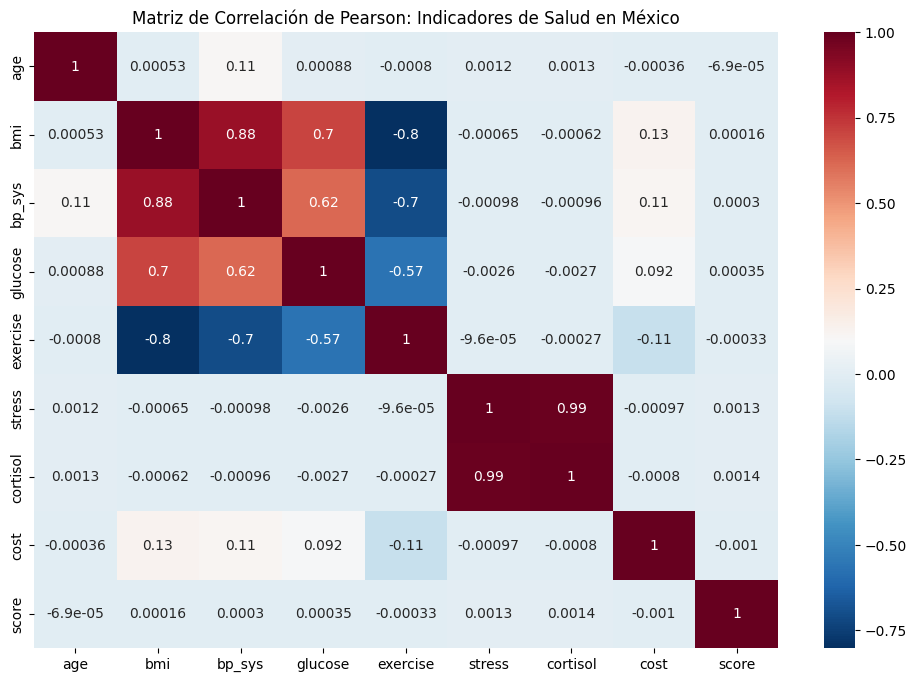

In [30]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r')

plt.title('Matriz de Correlación de Pearson: Indicadores de Salud en México')
plt.show()

In [31]:
corr_matrix

,age,bmi,bp_sys,glucose,exercise,stress,cortisol,cost,score
age,1.000000,0.000533,0.109102,0.000884,-0.000803,0.001238,0.001335,-0.000364,-0.000069
bmi,0.000533,1.000000,0.876756,0.704537,-0.801810,-0.000653,-0.000622,0.131418,0.000158
bp_sys,0.109102,0.876756,1.000000,0.617651,-0.704645,-0.000978,-0.000965,0.114752,0.000304
glucose,0.000884,0.704537,0.617651,1.000000,-0.565359,-0.002643,-0.002723,0.091960,0.000346
exercise,-0.000803,-0.801810,-0.704645,-0.565359,1.000000,-0.000096,-0.000268,-0.105063,-0.000334
stress,0.001238,-0.000653,-0.000978,-0.002643,-0.000096,1.000000,0.986648,-0.000971,0.001309
cortisol,0.001335,-0.000622,-0.000965,-0.002723,-0.000268,0.986648,1.000000,-0.000797,0.001369
cost,-0.000364,0.131418,0.114752,0.091960,-0.105063,-0.000971,-0.000797,1.000000,-0.001049
score,-0.000069,0.000158,0.000304,0.000346,-0.000334,0.001309,0.001369,-0.001049,1.000000


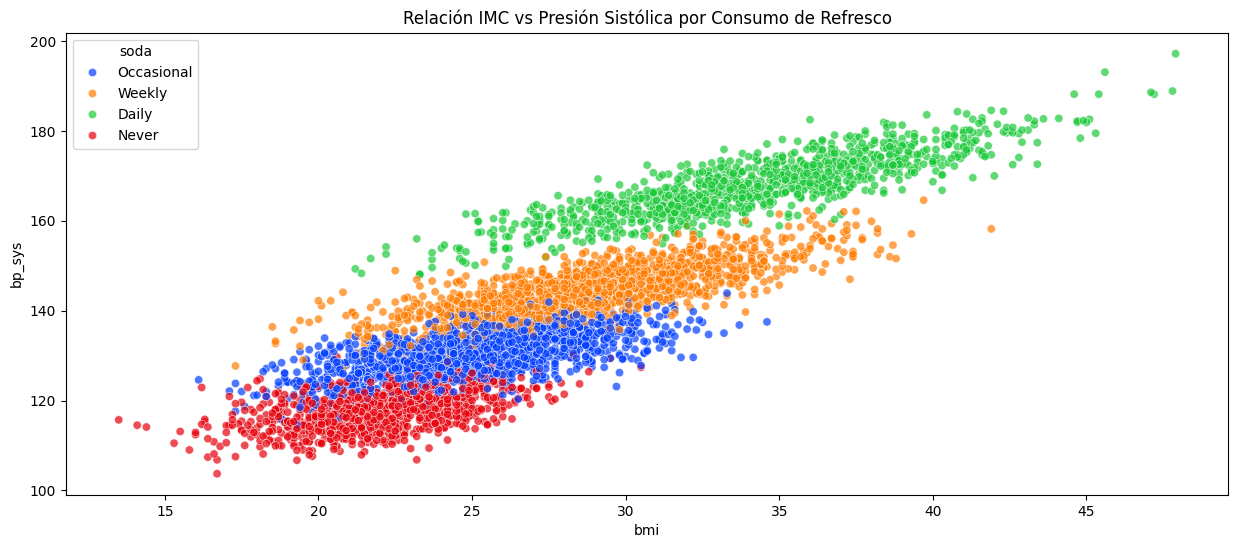

In [33]:
# Muestra para no colapsar la RAM
df_sample = df.sample(5000)

plt.figure(figsize=(15,6))
sns.scatterplot(data=df_sample, x='bmi', y='bp_sys', hue='soda', alpha=0.7, palette='bright')
plt.title('Relación IMC vs Presión Sistólica por Consumo de Refresco')
plt.show()

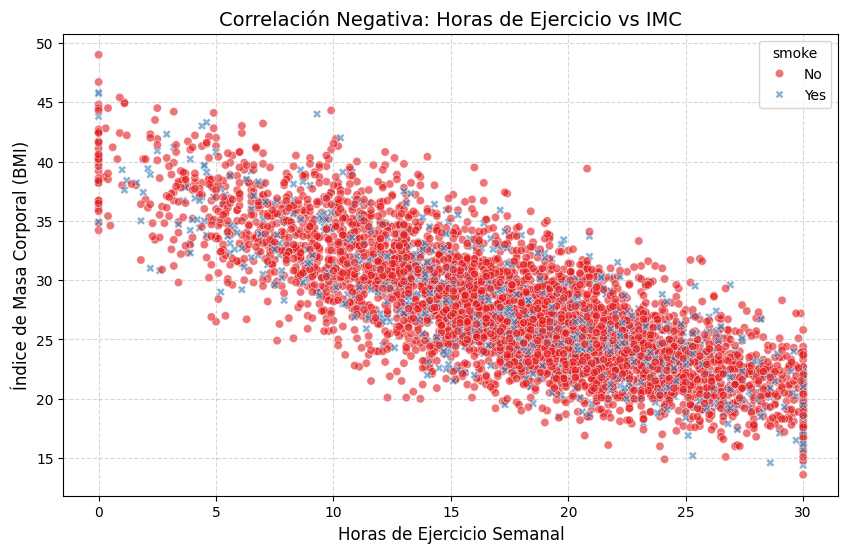

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# Muestra para claridad visual
df_sample = df.sample(5000)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_sample, 
    x='exercise', 
    y='bmi', 
    hue='smoke',      # Segmentamos por fumadores
    style='smoke',    # Diferente forma de punto para accesibilidad
    palette='Set1', 
    alpha=0.6
)

plt.title('Correlación Negativa: Horas de Ejercicio vs IMC', fontsize=14)
plt.xlabel('Horas de Ejercicio Semanal', fontsize=12)
plt.ylabel('Índice de Masa Corporal (BMI)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

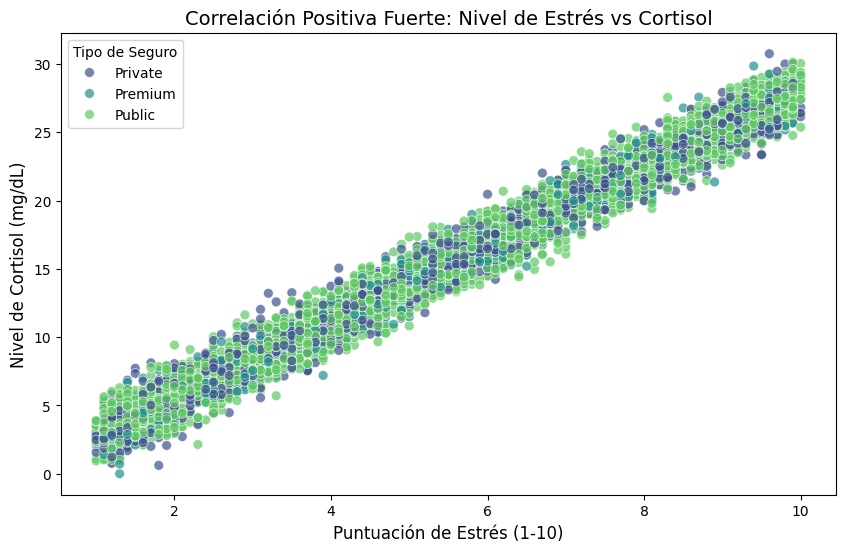

In [35]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_sample, 
    x='stress', 
    y='cortisol', 
    hue='insur',        # Segmentación por tipo de seguro
    palette='viridis', 
    s=50,               # Puntos un poco más grandes
    alpha=0.7
)

plt.title('Correlación Positiva Fuerte: Nivel de Estrés vs Cortisol', fontsize=14)
plt.xlabel('Puntuación de Estrés (1-10)', fontsize=12)
plt.ylabel('Nivel de Cortisol (mg/dL)', fontsize=12)
plt.legend(title='Tipo de Seguro', loc='upper left')
plt.show()

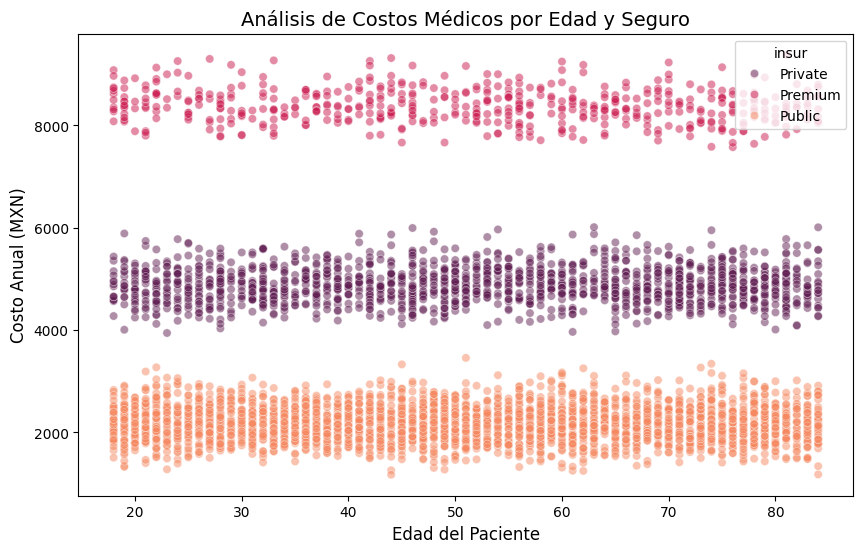

In [36]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_sample, 
    x='age', 
    y='cost', 
    hue='insur', 
    palette='rocket',
    alpha=0.5
)

plt.title('Análisis de Costos Médicos por Edad y Seguro', fontsize=14)
plt.xlabel('Edad del Paciente', fontsize=12)
plt.ylabel('Costo Anual (MXN)', fontsize=12)
plt.show()